任务：确定好串扰矩阵的形式（要不要加偏置），还要生成可以用来校准的矩阵（串扰矩阵的逆？）

In [ ]:
from src.common import run_script

res = run_script(
    "scripts.gen_data_crosstalk_flux",
    {
        "--out_npz":        "data/test_flux.npz",
        "--n":              10,
        "--k":              1000,
        "--z_scale":        0.3,
        "--quad_strength":  0.02,
        "--sat_strength":   0.05,
        "--per_strength":   0.02,
        "--noise_white":    0.01,
        "--noise_pattern":  0.005,
    }
)

print(res.stderr)

Running command:
  python -m scripts.gen_data_crosstalk_flux --out_npz data/test_flux.npz --n 10 --k 1000 --z_scale 0.3 --quad_strength 0.02 --sat_strength 0.05 --per_strength 0.02 --noise_white 0.01 --noise_pattern 0.005



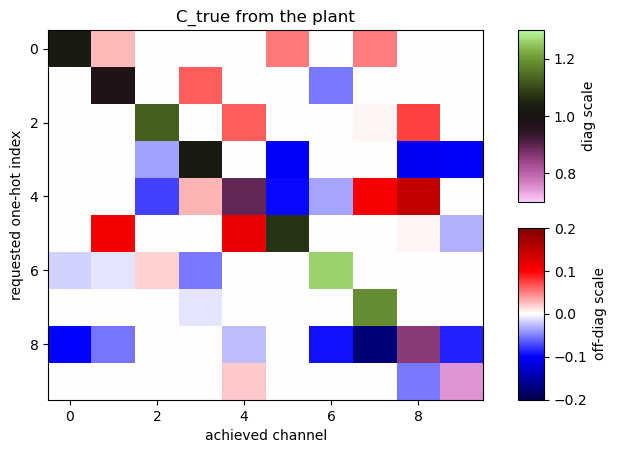

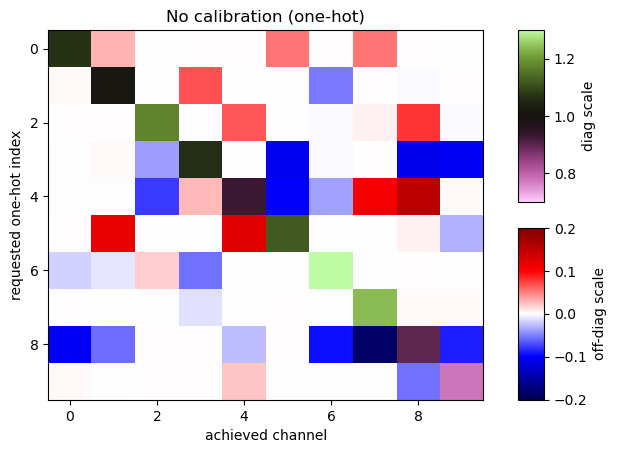

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from src.crosstalk import plot_matrix_two_colorbars

from src.crosstalk import (
    load_plant_from_npz, load_calibrator_pt,
    eval_onehot_blank, eval_onehot_calibrated,
)

d = np.load("data/test_flux.npz", allow_pickle=True)

plot_matrix_two_colorbars(
    d["C_true"].transpose(), 
    title="C_true from the plant",
    diag_range=(0.7,1.3), off_range=(-0.2,0.2), 
    show_abs_off=False
)
plt.show()

plant, cfg_dict, control, target, truth = load_plant_from_npz("data/test_flux.npz")
n = plant.cfg.n

_, _, T_ach_blank = eval_onehot_blank(plant, add_noise=False)

plot_matrix_two_colorbars(
    T_ach_blank,
    title="No calibration (one-hot)",
    diag_range=(0.7, 1.3),
    off_range=(-0.2, 0.2),
    show_abs_off=False,
)
plt.show()

In [2]:
import subprocess, json, os
from pathlib import Path

out_dir = "runs/xtalk_cal_test_flux"
Path(out_dir).mkdir(parents=True, exist_ok=True)

result = subprocess.run(
    [
        "python", "-m", "scripts.run_crosstalk_flux",
        "--in_npz", "data/test_flux.npz",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
)

print(result.stdout)
print(result.stderr) 

report_path = Path(out_dir) / "report.json"
report = json.loads(report_path.read_text(encoding="utf-8"))
report.keys(), report["models_ran"]


Wrote runs/invcal_test_flux_20260122_150833/report.json


=== Inverse calibration sweep summary (sorted by rmse_proxy) ===
+--------------+--------------+------------+-------------+
| model        | fit_time_sec | rmse_proxy | loss_last   |
+==============+==============+============+=============+
| residual_mlp | 2.16289      | 0.00406009 | 1.69392e-05 |
| mlp          | 3.37536      | 0.00654119 | 4.38172e-05 |
| linear       | 4.54163      | 0.0133167  | 0.000178055 |
+--------------+--------------+------------+-------------+
[artifacts] out_dir  = runs/invcal_test_flux_20260122_150833
[artifacts] report  = runs/invcal_test_flux_20260122_150833/report.json



(dict_keys(['task', 'in_npz', 'control_key', 'target_key', 'out_dir', 'out_json', 'device', 'dtype', 'N_samples', 'n_channels', 'train', 'models_ran', 'best_by_rmse_proxy', 'comparison_rows_sorted_by_rmse_proxy', 'per_model']),
 ['linear', 'mlp', 'residual_mlp'])

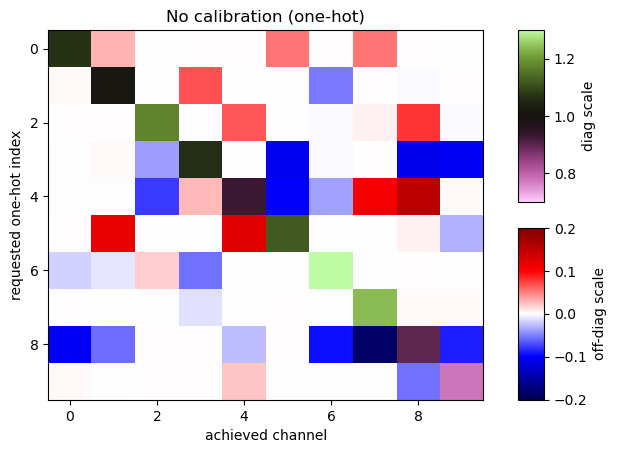

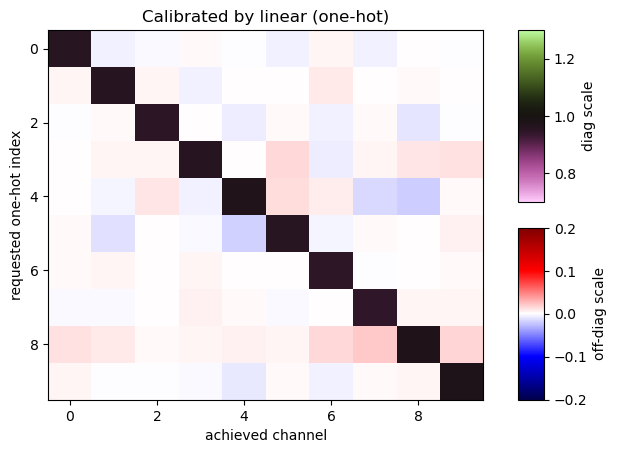

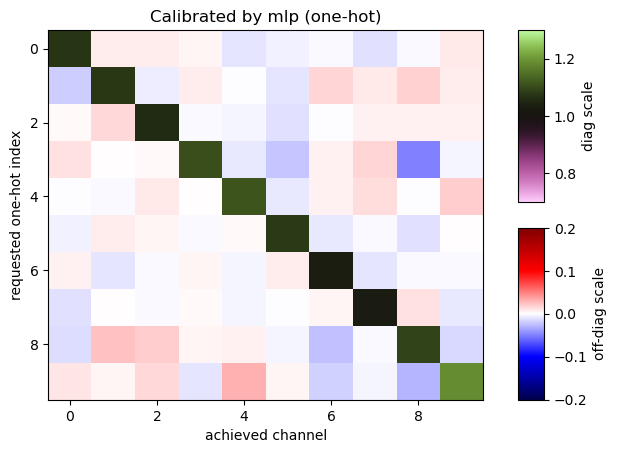

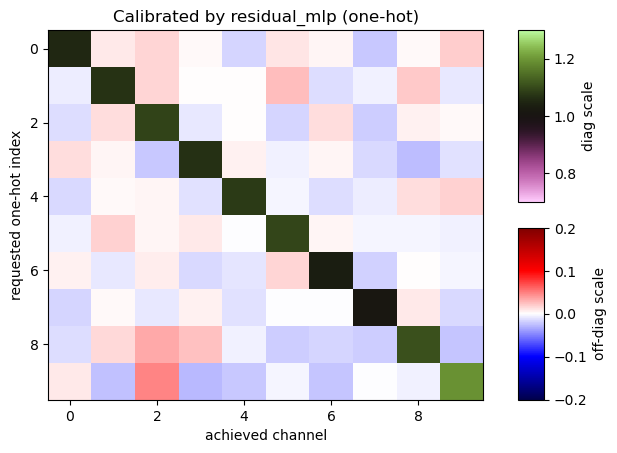

In [3]:
from src.crosstalk import (
    load_plant_from_npz, load_calibrator_pt,
    eval_onehot_blank, eval_onehot_calibrated,
)

plant, cfg_dict, control, target, truth = load_plant_from_npz("data/test_flux.npz")
n = plant.cfg.n

_, _, T_ach_blank = eval_onehot_blank(plant, add_noise=False)

plot_matrix_two_colorbars(
    T_ach_blank,
    title="No calibration (one-hot)",
    diag_range=(0.7, 1.3),
    off_range=(-0.2, 0.2),
    show_abs_off=False,
)
plt.show()

for mname in ["linear", "mlp", "residual_mlp"]:
    pt = report["per_model"][mname]["row"]["model_pt"]

    model, meta = load_calibrator_pt(pt, device="cpu")

    _, _, T_ach = eval_onehot_calibrated(plant, model, add_noise=False)

    plot_matrix_two_colorbars(
        T_ach,
        title=f"Calibrated by {mname} (one-hot)",
        diag_range=(0.7, 1.3),
        off_range=(-0.2, 0.2),
        show_abs_off=False,
    )
    plt.show()